# Introduction to Python Project : FoodHub Data Analysis

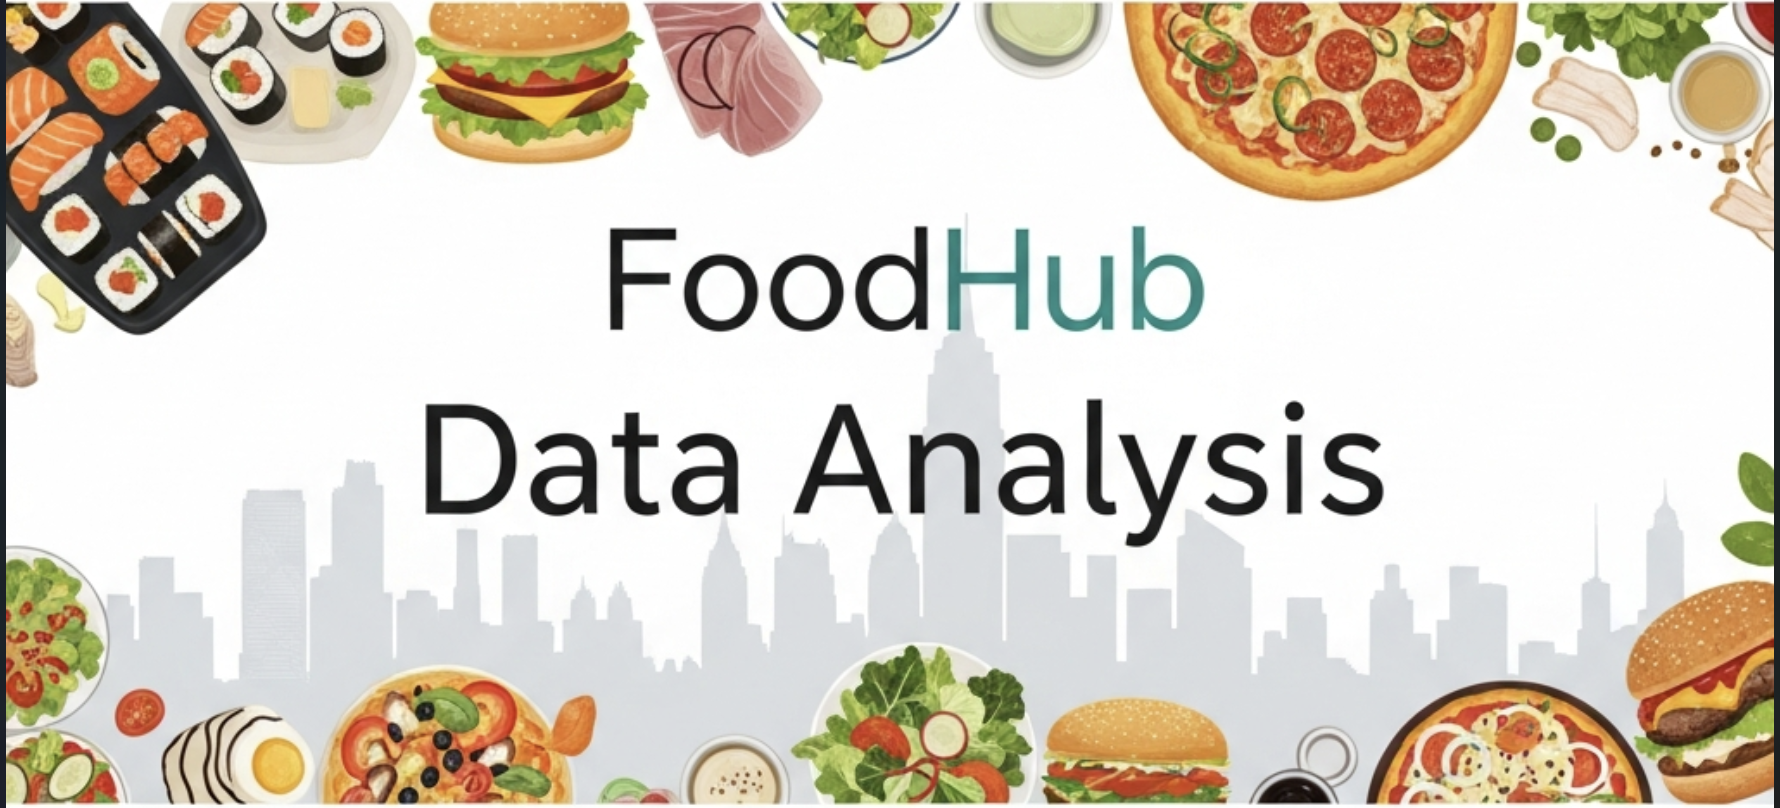

\*** *Image generated by Gemini 2.5 Pro, an AI-powered tool*

### Problem Statement

FoodHub is a fast-growing online food delivery aggregator in New York city. The platform connects it's registered customers with a wide network of restaurants by allowing them to place orders directly through the mobile app. With the increasing demand for online food delivery and a continuously expanding customer base, there's a need to understand the demand of various restaurants that helps to improve operational efficiency and enhance the overall customer experience.


### Objective

As a data scientist at FoodHub, the key objective is to analyse the dataset (stored data of the customers and their orders), identify patterns that can help the company better understand customer behaviour, restaurant performance and any operational bottlenecks.

This analysis will help enhancing customer satisfaction and improve it's business to take strategic decisions accordingly.

### Data Dictionary

This includes multiple food orders information

| Field | Detail |
| :------- | :------ |
| order_id  | Unique Identifier of the order  |
| customer_id  | Identifier of the customer who ordered the food|
| restaurant_name  | Name of the restaurant  |
| cuisine_type  | Type of Cuisine ordered by the customer  |
| cost_of_the_order  | Price of the order  |
| day_of_the_week  | Indicates if the order is placed on Weekend or Weekday (Mon-Fri - Weekend, Sat, Sun - Weekday)  |
| rating  | Rating provided by customer out of 5 |
| food_preparation_time  | Time (in minutes) taken by the restaurant to prepare the food. (Difference between timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation)  |
| delivery_time  | Time (in minutes) taken by the delivery person to deliver the food package. (Dfference between the timestamps of the delivery person's pick-up confirmation and drop-off information) |

### Let us start by importing the required libraries

In [1]:
# Import all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs
%matplotlib inline

#Display values upto 2 decimal places
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [2]:
# Import warnings package to supress the warnings
import warnings
warnings.filterwarnings('ignore')

### Understanding the structure of the data

In [3]:
# Mount GDrive to load required files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the Food Order CSV File

df_forders = pd.read_csv('/content/drive/MyDrive/PGP Course/Project - Food hub/foodhub_order.csv')

In [5]:
# Let's look at first 5 records

df_forders.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

1. The dataset is fairly structured data and contains the orders related information
2. Rating column has 'Not given' values for few records, let's check them

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Find out the shape of the file

df_forders.shape

(1898, 9)

In [7]:
# Display the rows and columns

print(f"The dataset has {df_forders.shape[0]} rows and {df_forders.shape[1]} columns")

The dataset has 1898 rows and 9 columns


#### Observations:

The dataset contains **1898** rows and **9** columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [8]:
# Verify the information of the order dataset

df_forders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

1. The dataset contains 5 numerical columns (4 integer, 1 float) and 4 object columns (non-numeric)
2. The dataset doesn't show any NULL values
3. Restaurant Name, Cuisine type, day of the week columns are of object datatype, which is fairly valid, as they contain string values.
3. However, the rating column is of **object** datatype, because it contains non-numeric values and seems in-correct
4. From the first 5 records, it is clear that 'Not given' is provided as the rating for few records, and it highlights that rating is missing for some cuisines of few restaurants






### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [9]:
# Count how many 'Not given' values are present in Rating column

missing_ratings_count = (df_forders['rating'] == 'Not given').sum()

print('Count of the records with missing ratings:', missing_ratings_count)

Count of the records with missing ratings: 736


#### Observations:

There are 736 records in the dataset that has missing rating values. Let's correct this


#### Treat missing data - Replace missing values with NaN

In [10]:
# Replace all 'Not Given' ratings with NumPy's NaN (Not a Number)

df_forders['rating'] = df_forders['rating'].replace('Not given', np.nan)

# Convert 'rating' from Object to Numeric, so that it can be used for analysis going forward

df_forders['rating'] = df_forders['rating'].astype(float)

##### **Observations:**

1. Here, we are treating missing values by replacing 'Not given' with NaN
2. Since there are around 736 records that have missing ratings, the approach considered here is to replace with NaN and not to impute with mean/median, as they could significantly affect restaurant's performance


In [11]:
df_forders.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24


In [12]:
# Let's check the details of the dataset

df_forders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


#### Observations

1. Now we have 2 float columns.
2. The 'rating' column originally contained 'Not given' values. These have been replaced with np.nan.
3. Rating column is now updated to float data type

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [13]:
# Verify the statistical summary of the data set for numerical columns

df_forders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
rating,1162.00,4.34,0.74,3.00,4.00,5.00,5.00,5.00
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### Observations:

1. order_id and customer_id are unique ID's and are of not much use for distribution checks
2. Once the order is placed, time for preparing food takes around 20 mins minimum, 35 mins maximum and average of around ~27.37 mins
    * Minimum Food Preparation Time: 20 mins
    * Maximum Food Preparation Time: 35 mins
    * Average Food Preparation Time: 27.37 mins
3. Once the food is prepared, time for delivering the food takes around 15 mins minimum, maximum of 33 minutes and an average of ~24.16 mins.
    * Minimum Food Delivery Time: 15 mins
    * Maximum Food Delivery Time: 33 mins
    * Average Food Delivery Time: 24.16 mins
4. 75% of the orders cost around 22.30 or less, suggesting a right skewed distribution where more orders are on the lower to mid price range
5. A significant portion of the rated orders have a perfect score, as both 50th percentile (median) and 75th percentile are 5.00, with less standard deviation
6. Mean is slightly less than median for delivery time variable, suggesting a slight left-skewed distribution

### **Question 5:** How many orders are not rated? [1 mark]

In [14]:
# Let's find out the orders that are not rated

non_rated_orders = df_forders['rating'].isnull().sum()

print('Count of orders that are not rated: ', non_rated_orders)

Count of orders that are not rated:  736


#### Observations:

Since Not given ratings are converted to np.nan, these are listed as non-rated columns

### Exploratory Data Analysis (EDA)

### Univariate Analysis

*order_id* and *customer_id* are unique Identifiers and doesn't help much in the univariate analysis.

Let's first find out the numerical and categorical variables from the dataset.

Numerical Variables:

* cost_of_the_order
* food_preparation_time
* delivery_time

Categorical variables:

* cuisine_type
* day_of_the_week
* rating

NOTE: However, rating can also come under ordinal variables, with specific meaning behind the ratings of the restaurant

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### cost_of_the_order

Let's check the distribution of **cost_of_the_order** variable.

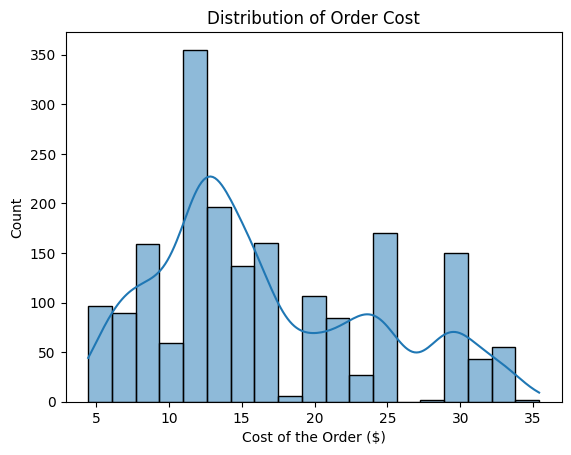

In [15]:
# Plot histogram for numerical variable cost_of_the_order

plt.title('Distribution of Order Cost')
plt.xlabel('Cost of the Order ($)')
sns.histplot(data=df_forders, x='cost_of_the_order', kde=True)
plt.show()

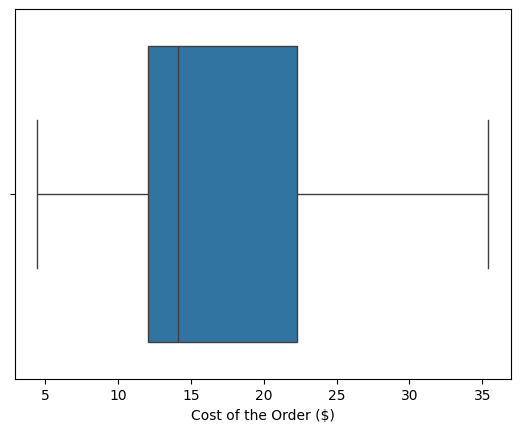

In [16]:
# Plot boxplot for numerical variable cost_of_the_order

plt.xlabel('Cost of the Order ($)')
sns.boxplot(data=df_forders, x='cost_of_the_order')
plt.show()

##### Observations

1. Histogram KDE plot shows multiple peaks, suggesting low, mid-range and high range orders
2. Both the plots shows that the data is positively skewed (right-skewed), most of the orders are relatively lower cost, but a small number of orders are significantly more expensive.
3. The median order cost is around \$14, as shown in the box plot
4. The mean(~16.50) is higher than median due to right skew caused by high cost orders
5. Box plot shows there are no outliers in the distribution suggesting the variability in the cost is normal
6. The most frequent orders cost is around 12\$ with almost ~350 orders in the range
7. The IQR ranges from \$12 to \$23, indicating that 50% of the orders fall within this cost band.

#### food_preparation_time

Let's check the distribution of **food_preparation_time** variable.

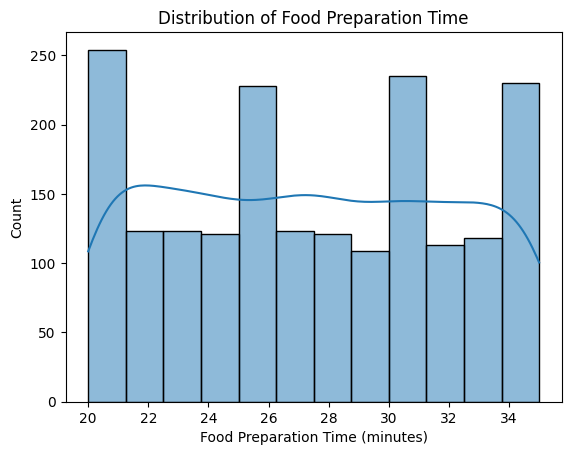

In [17]:
# Plot histogram for numerical variable food_preparation_time

sns.histplot(data=df_forders, x='food_preparation_time', kde=True)
plt.title('Distribution of Food Preparation Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.show()

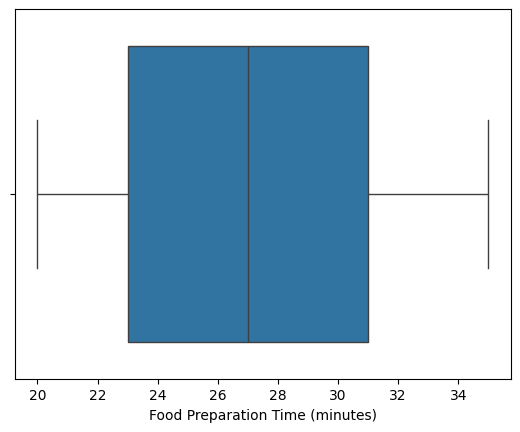

In [18]:
# Plot boxplot for numerical variable food_preparation_time

plt.xlabel('Food Preparation Time (minutes)')
sns.boxplot(data=df_forders, x='food_preparation_time')
plt.show()

##### Observations

1. The distribution is relatively uniform(flat), all bins have roughly similar heights suggesting food preparation times are spread almost evenly between 20 and 35 minutes.
2. The median is at approx 27.5 mins, which is almost perfectly at the center.
3. The whiskers are almost of equal length, ***however right whisker is slight more longer compared with left whisker*** and suggest no outliers in the plot,
4. It shows flat pattern where all the bars are of roughly similar heights.
5. Most of the food preparation time is equally distributed around ~23 to 31 mins
6. The distribution does not show normal bell shape; it appears almost uniform. This indicates that restaurants differ widely in their preparation speed, with no dominant time range.

#### delivery_time

Let's check the distribution of delivery_time variable.

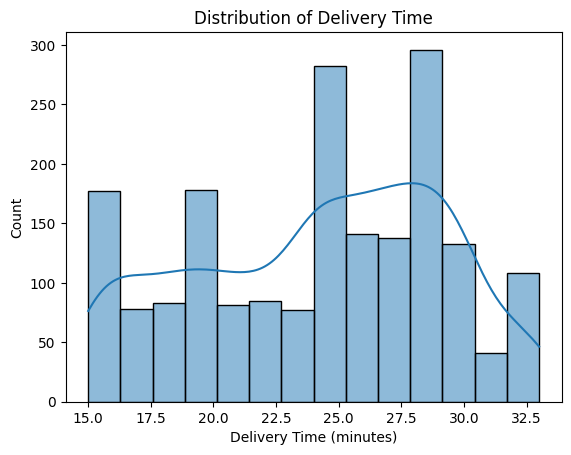

In [19]:
# Plot histogram for numerical variable delivery_time

sns.histplot(data=df_forders, x='delivery_time', kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.show()

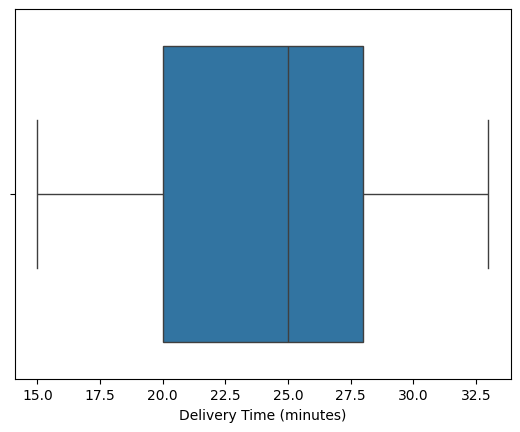

In [20]:
# Plot boxplot for numerical variable delivery_time

plt.xlabel('Delivery Time (minutes)')
sns.boxplot(data=df_forders, x='delivery_time')
plt.show()

##### Observations

1. Histogram KDE plot shows multiple peak times, and this isn't a smooth bell curve. Suggest delivery conditions vary from long distances to short distances
2. Both the plots shows that the data is slightly negatively skewed (left-skewed), with no outliers in the distribution
3. Box plot shows that the median value is around 25 mins, indicating around half of the deliveries takes 25 mins or less
4. As the left tail is more, this suggests average time(mean) is less than the median
5. Most of the delivery times falls between 20 to 30 mins

#### cuisine_type

Let's check the frequency distribution of **cuisine_type** feature

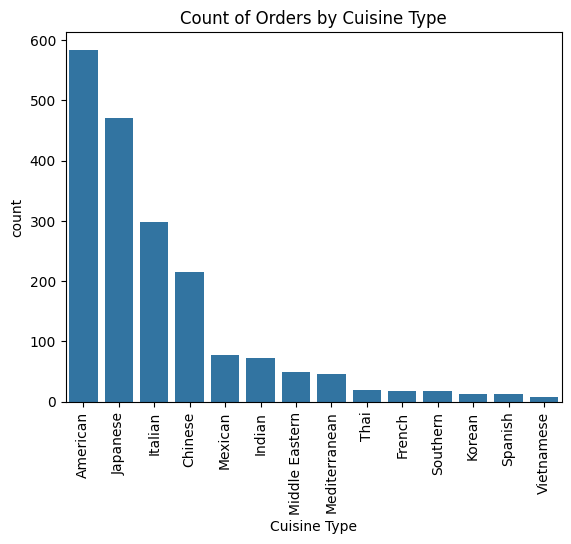

In [21]:
# Plot countplot for categorical variable cuisine_type

sns.countplot(data=df_forders, x='cuisine_type', order=df_forders['cuisine_type'].value_counts().index)
plt.title('Count of Orders by Cuisine Type')
plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.show()

##### Observations

1. The frequency distribution suggests American cuisine has highest orders of around ~580
2. Followed by Japanese orders nearing to ~480 orders
3. Top three cuisines are America, Japanese and Italian.
4. However, bottom three less popular cuisines are Vietnamese, Spanish and Korean



#### day_of_the_week

Let's check the frequency distribution of **day_of_the_week** feature

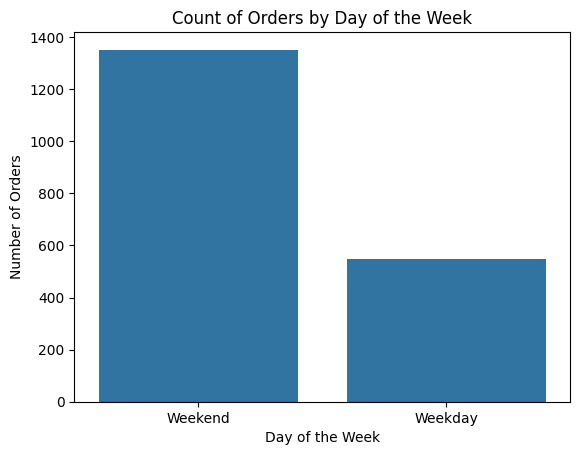

In [22]:
# Plot countplot for categorical variable day_of_the_week

sns.countplot(data=df_forders, x='day_of_the_week')
plt.title('Count of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.show()

##### Observations

1. The frequency distribution shows Weekend (Saturday and Sunday) have highest orders nearing ~1400 orders
2. Relatively Weekdays have less orders of around ~580-600


#### rating

Let's check the frequency distribution of **rating** feature

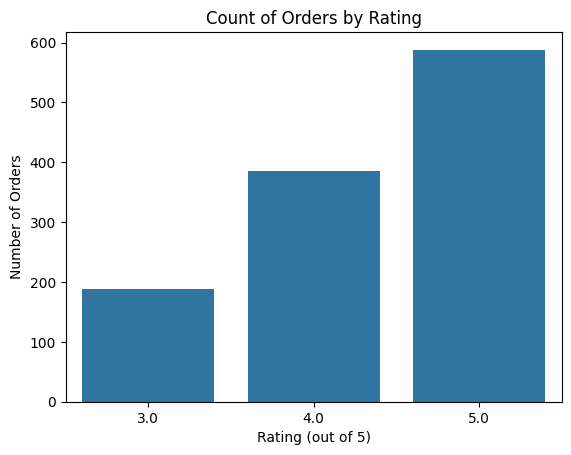

In [23]:
# Plot countplot for variable rating

sns.countplot(data=df_forders, x='rating')
plt.title('Count of Orders by Rating')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Orders')
plt.show()

##### Observations

1. Maximum orders received 5.0 ratings, suggesting the reviews are good for most of the orders
2. Around ~600 orders received 5 rating
3. Followed with 4.0 rating (for ~390-400 orders) and 3.0 rating (for ~190-200 orders)


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [24]:
# Fetch top 5 restaurant names that has highest number of orders

top5_restaurants = df_forders['restaurant_name'].value_counts().head() # head() by default returns top 5 rows

print("Top 5 restaurants by number of orders:")
print(top5_restaurants)

Top 5 restaurants by number of orders:
restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:

1. The top 5 restaurants that received highest number of orders are:

    * Shake Shack
    * The Meatball Shop
    * Blue Ribbon Sushi
    * Blue Ribbon Fried Chicken
    * Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [25]:
# Fetch orders that are placed on Weekend
weekend_orders = df_forders[df_forders['day_of_the_week'] == 'Weekend']

# Capture the most popular cuisine from the fetched orders - mode returns the most frequent value
weekend_orders['cuisine_type'].mode()[0]

'American'

#### Observations:

1. The most popular cuisine on weekends is 'American'
2. This can be found by calculating mode (most frequent value) against cuisine type

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [26]:
# Fetch orders that cost more than 20 dollars

few_orders = df_forders[df_forders['cost_of_the_order'] > 20]

# Calculate percentage by dividing the subset orders count with the actual orders count and multiply by 100

orders_perc = ((few_orders.shape[0])/df_forders.shape[0]) * 100

print(f'Percentage of orders that cost more than 20 dollars: {orders_perc:.2f}%')

Percentage of orders that cost more than 20 dollars: 29.24%


#### Observations:

1. It has been observed that around 29.24% of orders cost more than 20 dollars

### **Question 10**: What is the mean order delivery time? [1 mark]

In [27]:
# Calculate average order delivery time

avg_time = df_forders['delivery_time'].mean()

print(f'Average order delivery time: {avg_time:.2f} mins')

Average order delivery time: 24.16 mins


#### Observations:

1. Approximate average/mean delivery time is 24.16 minutes


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [28]:
# Fetch top 3 customer ID's that ordered frequently

# value_counts() count the occurences of customer id, head(3) returns top 3 customers
most_frequent_customers = df_forders['customer_id'].value_counts().head(3)

print("Top 3 most frequent customers:")
print(most_frequent_customers)

Top 3 most frequent customers:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:

1. Customer Id 52832 ordered 13 times
2. Customer Id 47440 ordered 10 times
3. Customer Id 83287 ordered 9 times


### Multivariate Analysis

Let's try to understand the relation between numerical variables, and also between numerical and categorical variables which we have identified earlier.

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Correlation Analysis - Numerical Variables

First let's analyse relationship between **numerical** **variables**

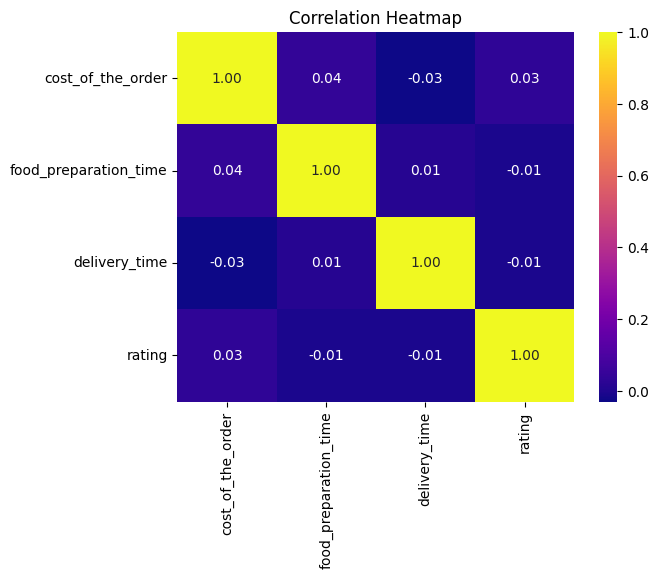

In [29]:
# Correlation Heatmap (Numerical vs Numerical)

# Only numeric columns are used for correlation
# However Rating (Ordinal variable) is also included to understand the relation of rating with other variables

numeric_df = df_forders[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']]
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='plasma', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observations:

1. It is clearly evident that there is no linear relationship between any of these variables
2. Expensive food doesn't guarantee highest rating, nor does less expensive food lead to lowest ratings. Price is irrelevant to ratings here
3. Cost of the order, delivery time and food preparation time are not related to each other. Any change in one variable doesn't impact others
4. This correlation analysis shows that all these variables are independent to each other. Also customer rating is not driven by either order cost, or speed of delivery

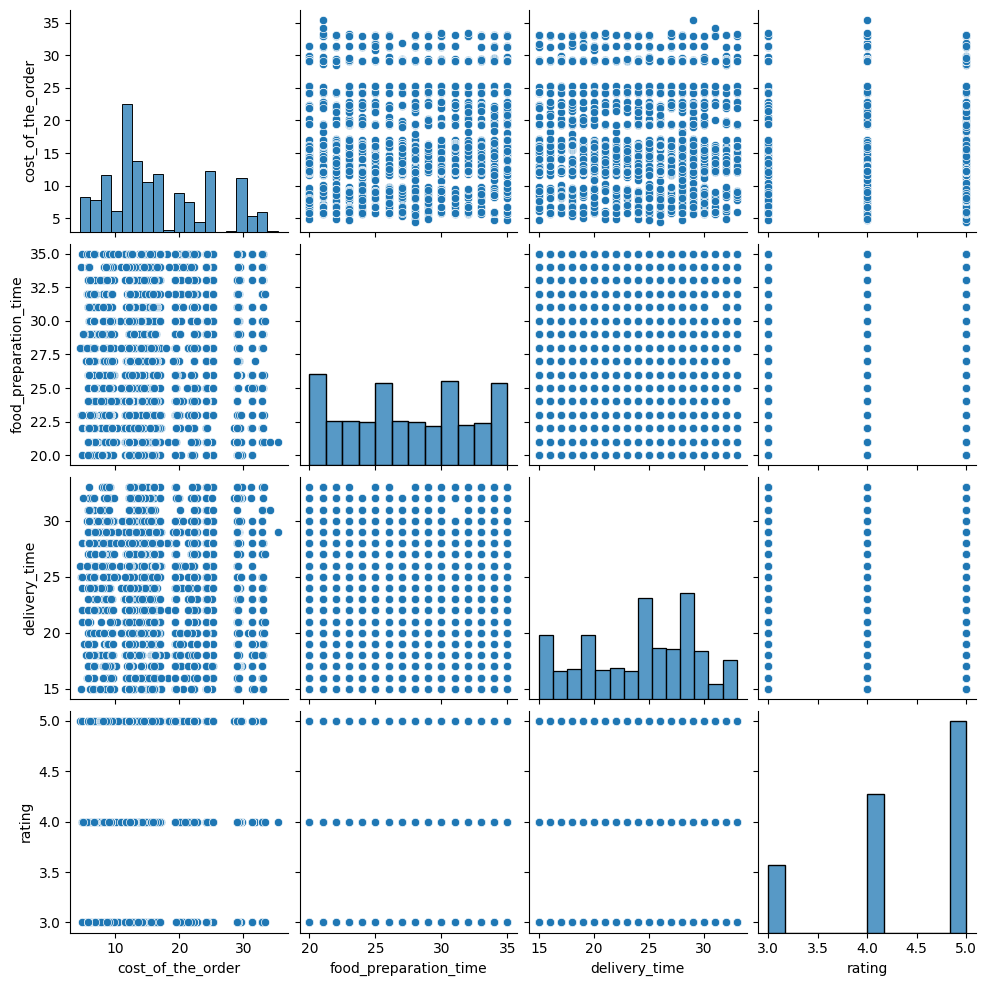

In [30]:
# Let's find out the relation between numerical variables with pairplot

numeric_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
sns.pairplot(data=df_forders, x_vars=numeric_list, y_vars=numeric_list)
plt.show()

**Observations:**

1. This pairplot also confirms that cost, delivery time and preparation time are independent variables
2. Ratings do not co-relate with cost or speed

#### Now, let's explore relation between numerical and categorical variables

#### cost_of_the_order vs cuisine_type

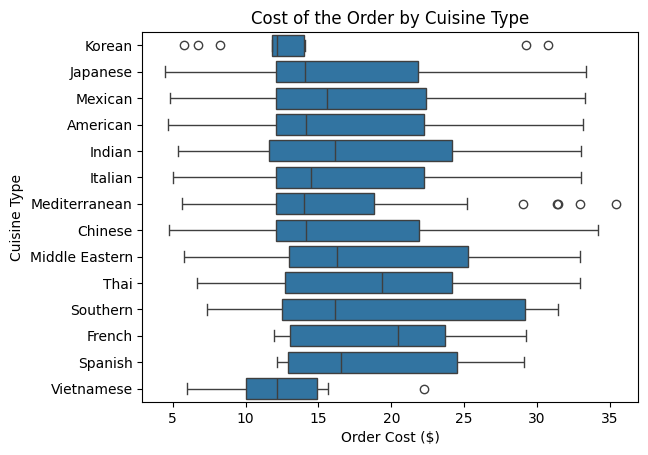

In [31]:
# Cuisine Type vs Cost of Order (Categorical vs. Numerical)
sns.boxplot(data=df_forders, x='cost_of_the_order', y='cuisine_type')
plt.title('Cost of the Order by Cuisine Type')
plt.xlabel('Order Cost ($)')
plt.ylabel('Cuisine Type')
plt.show()

##### Observations:

1. On Average, French cuisine appears to be the most expensive, with the highest median cost around \$20-\$21
2. Vietnamese and Korean cusines are least expensive, with median costs around \$12-\$13, and their majority of the orders falls under lowest price range
3. Mediterranean and Korean cuisines shows several price outliers suggesting their average price is moderate, and occasional price is expensive
4. Vietnamese is the best option for cheap meal, while French is expensive one. For predictable pricing, Korean cuisine is best

#### food_preparation_time vs cuisine_type

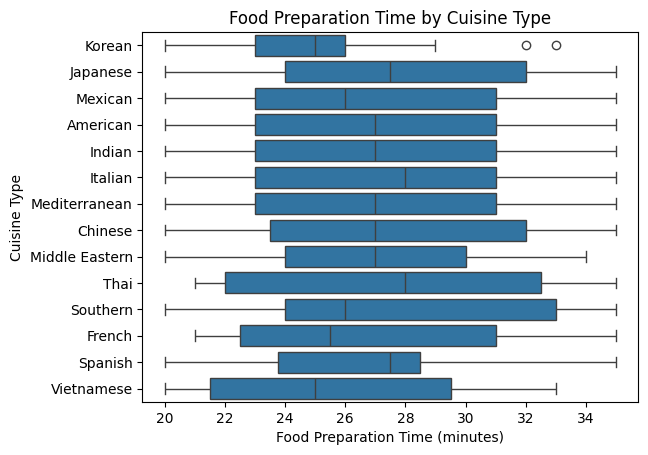

In [32]:
# Cuisine Type vs. Food Preparation Time (Categorical vs. Numerical)

sns.boxplot(data=df_forders, x='food_preparation_time', y='cuisine_type')
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Food Preparation Time (minutes)')
plt.ylabel('Cuisine Type')
plt.show()

Observations:

1. Italian and Thai cuisines shows highest median preparation time, around 28-29 mins, suggest these are slowest cuisines
2. Korean cuisine has lowest median time (~25 mins), followed by Vietnamese, which are the quickest options
3. Southern, Japanese, Chinese shows highest preparation times at 75%, accounting to ~32-33min
4. Korean shows high end outliers, meaning that while orders are prepared quickly, some take usually longer time

#### day_of_the_week vs delivery_time

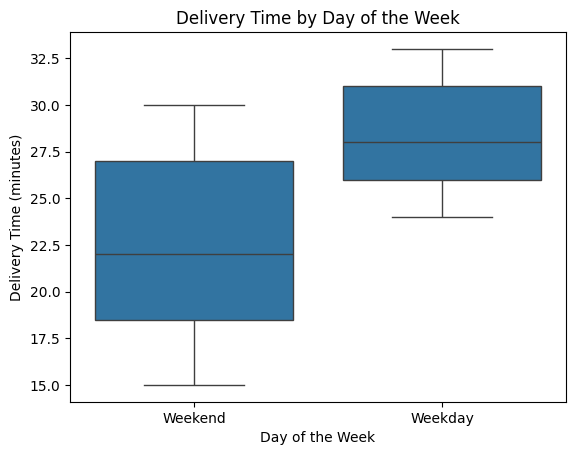

In [33]:
# Day of the week vs. Delivery Time (Categorical vs. Numerical)

sns.boxplot(data=df_forders, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()

Observations:

1. Weekend deliveries are faster, the median delivery time for weekends is around ~22 mins
2. The median for weekdays shows the delivery time is much slower, at about 28 minutes.
3. The fastest delivery times occur only on Weekend, with minimum time of 15 mins, whereas during Weekdays, it is much slower of about ~24 mins

#### cuisine_type vs rating

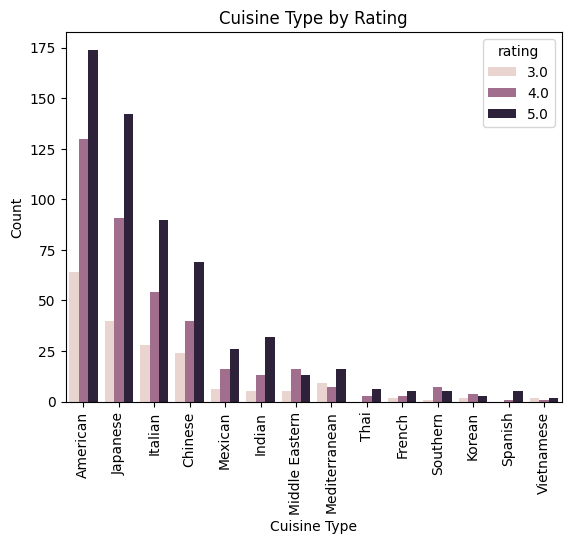

In [34]:
# Count plot with hue 'rating' to understand the ratings of cuisines

sns.countplot(data=df_forders, x='cuisine_type', hue='rating', order=df_forders['cuisine_type'].value_counts().index)
plt.title('Cuisine Type by Rating')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

Observations:

1. Top cuisines American, Japanese and Italian receive overall highest number of ratings
2. Most of the cuisines have highest ratings according to the orders that are placed

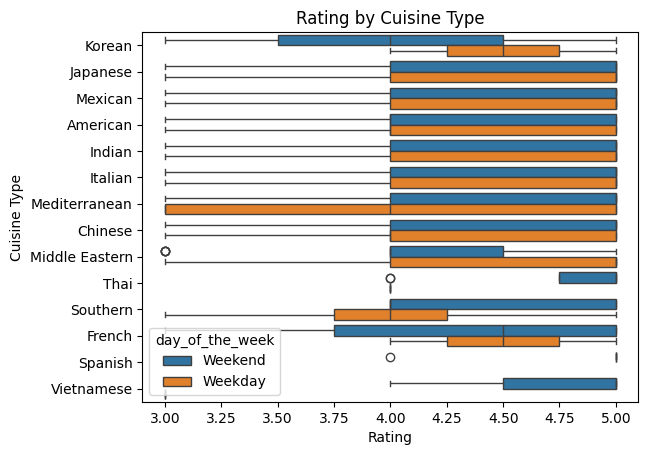

In [35]:
# Cuisine Type vs. Rating - Boxplot to understand relation between rating and cuisine type

sns.boxplot(data=df_forders, x='rating',y='cuisine_type', hue='day_of_the_week')
plt.title('Rating by Cuisine Type')
plt.ylabel('Cuisine Type')
plt.xlabel('Rating')
plt.show()

Observations:

1. Across weekdays and weekends, almost all the cuisines have very high ratings (4.0 - 5.0), signifies good customer satisfaction nearly for all the cuisines
2. Vietnamese and Mediterranean have the widest spread, with minimum of 3.0 rating and max of 5.0 rating
3. Spanish cuisine has high consistency, with almost 50% of ratings is condensed at 5.0, there's only one visible outlier at 4.0 rating
4. For most of the cuisines, the majority of ratings falls under 4.0 to 5.0, suggests the customer has 75% chance of providing a rating of 4.0 or higher
5. There are only subtle shifts in variations during weekdays and weekends for few cuisines, but these differences doesn't show major issues.

#### cuisine_type vs day_of_the_week

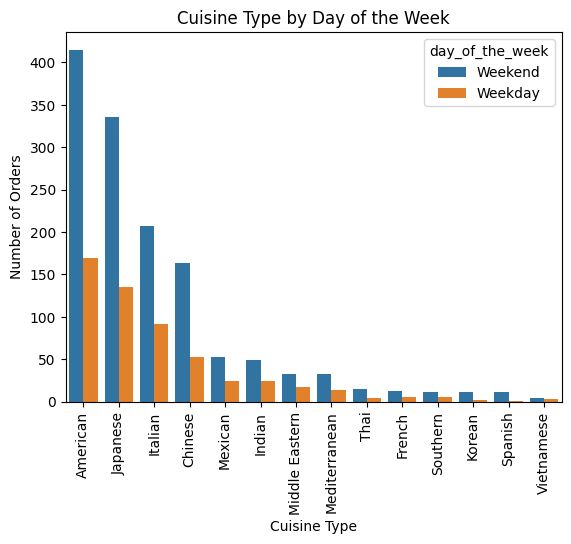

In [36]:
# Understand relation between categorical variables - cuisine type and day of the week

sns.countplot(data=df_forders, x='cuisine_type', hue='day_of_the_week',
              order=df_forders['cuisine_type'].value_counts().index)
plt.title('Cuisine Type by Day of the Week')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.show()

##### Observations:

1. Weekend orders are more for top cuisines like American, Japanese and Italian
2. It also suggests weekend orders are more for almost all the cuisines

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [37]:
# Drop out the orders that were not rated
df_rated = df_forders.dropna(subset=['rating'])

# Group by restaurant name and aggregate the count and mean of ratings
restaurant_stats = df_rated.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Apply the filter conditions
# 1. Rating count > 50
# 2. Average rating > 4
promo_restaurants = restaurant_stats[
    (restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)
]

print("Restaurants eligible for the promotional offer:")
print(promo_restaurants)

Restaurants eligible for the promotional offer:
                           count  mean
restaurant_name                       
Blue Ribbon Fried Chicken     64  4.33
Blue Ribbon Sushi             73  4.22
Shake Shack                  133  4.28
The Meatball Shop             84  4.51


#### Observations:

1. In the first step, we dropped records that doesn't have any ratings, i.e., that have missed ratings, since our analysis is on the data that have a rating value
2. Dataset is grouped by restaurant name, and count, mean was calculated on the rating column
3. There are 4 restaurants from the dataset that have a rating score of more than 50, with average greater than 4
    * Blue Ribbon Fried Chicken - 64 - 4.33
    * Blue Ribbon Sushi - 73 - 4.22
    * Shake Shack - 133 - 4.28
    * The Meatball Shop - 84 - 4.51




### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [38]:
# Define the function to calculate the revenue
def cal_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0  # No revenue for orders $5 or less

# Apply this function to create a new 'revenue' column
df_forders['revenue'] = df_forders['cost_of_the_order'].apply(cal_revenue)

# Calculate the total revenue
net_revenue = df_forders['revenue'].sum()

print(f"The total net revenue generated by FoodHub is: ${net_revenue:.2f}")

The total net revenue generated by FoodHub is: $6166.30


#### Observations:

1. To find out net revenue, calculate_revenue function is defined with the formulae.
2. Orders costing more than 20 dollars accounts to 25% of charges, while orders costing more than 5 dollars accounts to 15% of charges
3. The total net revenue generated by FoodHub from the dataset is $6166.30


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [39]:
# Calculate total time (preparation + delivery)
# Add this as a column to the dataset
df_forders['total_time'] = df_forders['food_preparation_time'] + df_forders['delivery_time']

# Count orders taking more than 60 minutes
orders_over_60_min = df_forders[df_forders['total_time'] > 60].shape[0]

# Calculate the percentage
total_orders = df_forders.shape[0]
percentage_cal = (orders_over_60_min / total_orders) * 100

print(f"Percentage of orders taking more than 60 minutes: {percentage_cal:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:

1. A new column is added that holds the total time which is the sum of food preparation time and delivery time.
2. From the dataset provided, around 10.54% of orders take more than 60 minutes to deliver the food. This includes preparation time and delivery time


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [40]:
# Group by 'day_of_the_week' and calculate average 'delivery_time'
# mean is used to calculate average
average_delivery_by_day = df_forders.groupby('day_of_the_week')['delivery_time'].mean()

print("Mean delivery time (in mins) by day of the week:")
print(average_delivery_by_day)

Mean delivery time (in mins) by day of the week:
day_of_the_week
Weekday   28.34
Weekend   22.47
Name: delivery_time, dtype: float64


#### Observations:

1. During Weekday (Mon - Fri), the average delivery time is around ~28.34 mins
2. During Weekend (Sat, Sun), the average delivery time is around ~22.47 mins
3. This suggests that the weekend deliveries are faster than weekday deliveries

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

Based on the comprehensive analysis, here are the key conclusions that are drawn from customer behaviour, restaurant performance and other operational metrics:

1. **Demand and Popularity:**

    * Orders are significantly higher on **weekends** (more than 70%) nearly 1400, compared to weekdays (around 550-600), indicating peak demand during the free times.
    * **American, Japanese and Italian** cuisines are the most popular cuisines, especially on weekends, accounting for signficant demand of all the orders.
    * Shake Shack (219 orders), The Meatball Shop (132) and Blue Ribbon Sushi (119) restaurants receive highest number of orders

2. **Preparation and Delivery Times:**

    * Food preparation takes an average at 27.37 minutes, with Italian and Thai cuisines are slowest, while Korean/Vietnamese cuisines have the lowest preparation times and are fastest.

    * Delivery time averages at 24.16 minutes but seems faster on weekends despite higher order volume than weekdays.

    * Overall, 10.54% of orders takes longer than an hour from placement to delivery, which could lead to customer dissatisfaction.

3. **Customer satisfaction and ratings:**

    * Most of the ratings are generally high (average of 4.34), with the most falling between 4.0 to 5.0, indicates strong customer satisfaction

    * However, around 736 (39%) orders lack ratings which is making it difficult to accurately assess customer satisfaction

    * No strong correlation exists between ratings, cost, prep time or delivery time suggestion that the customer satisfaction is driven by factors beyond speed or cost like food quality or consistency

4. **Cost and Revenue Insights:**

    * The average order cost is ~16 dollars, with 29% of orders exceeding \$20. This pricing structure generates a net revenue of \$6166.30 for FoodHub based on the commissions.

    * French cuisine is the most expensive (median ~21\$), while Vietnamese and korean are the most affordable (median ~12-13\$).

    * This suggests affordability influences order volume for certain cuisines.

### Recommendations:


To enhance customer satisfaction and to help improve the business of FoodHub, here are actionable recommendations based on the findings:

1. **Partnerships:**

    * Partner closely with popular and high performing restaurants like Shake Shack, The Meatball Shop and Blue Ribbon Sushi, which also have high ratings and high volume of the orders. Offer targeted promotions to these restaurants, reward top frequent customers (Ex: Additional 10% discounts) to encourage loyalty and more orders

2. **Promotions:**
    * Focus on promotions, come up with few ad campaigns on popular cuisines like American, Japanese and Italian, which drive majority of customer orders and represent biggest revenue opportunitites. Ensure there is a good variety and quality of options in these categories.

    * For budget friendly cuisines like Korean, Vietnamese provide in-app recommendations to attract price sensitive customers. (Ex: Quick meal in 20 mins, meal value campaigns)

    * For underperforming cuisines with high ratings like Spanish, run marketing campaigns to increase visibility and orders. (Ex: Top rated hidden gems)

3. **Improve Ratings:**
    * Encourage ratings for all the orders inorder to reduce 39% of missing data by providing reward points for rating, send messages or prompts post delivery of the order, ask customers to provide 1 tap/quicker feedback before going for detailed one. This will add more data to the analysis and help identify under performing restaurants

4. **Improve Weekday Deliveries:**
    * Weekday deliveries are significantly lower than weekend deliveries, and this could be because of the traffic, less available delivery partners or restaurant delays. Consider increasing driver availability during weekday peak hours. Provide 'priority delivery' incentives for drivers on weekdays.

5. **Improve Delivery times:**
    * For ~10% of the orders taking over 60 minutes delivery, try to understand the orders that comes under this category. Prioritise such orders early, route them to nearby drivers and also flag slow restaurants to optimise the process (Ex: Have some pre-prep work done upfront). This can help in reducing long wait dissatisfaction.